In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import urllib.request
import re

In [2]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
text = urllib.request.urlopen(url).read().decode('utf-8')[:1000]
words = re.findall(r'\w+', text.lower())
vocab = list(set(words))
word2idx = {w: i for i, w in enumerate(vocab)}

In [3]:
pairs = []
for i in range(1, len(words)-1):
    target = word2idx[words[i]]
    context = [word2idx[words[i-1]], word2idx[words[i+1]]]
    for c in context:
        pairs.append((target, c))
X = torch.LongTensor([p[0] for p in pairs]).to(device)
y = torch.LongTensor([p[1] for p in pairs]).to(device)

In [4]:
class CBOW(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(len(vocab), 2)
        self.fc = nn.Linear(2, len(vocab))
    def forward(self, x):
        return self.fc(self.embed(x))

In [5]:
model = CBOW().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
for epoch in range(50):
    optimizer.zero_grad()
    out = model(X)
    loss = criterion(out, y)
    loss.backward()
    optimizer.step()

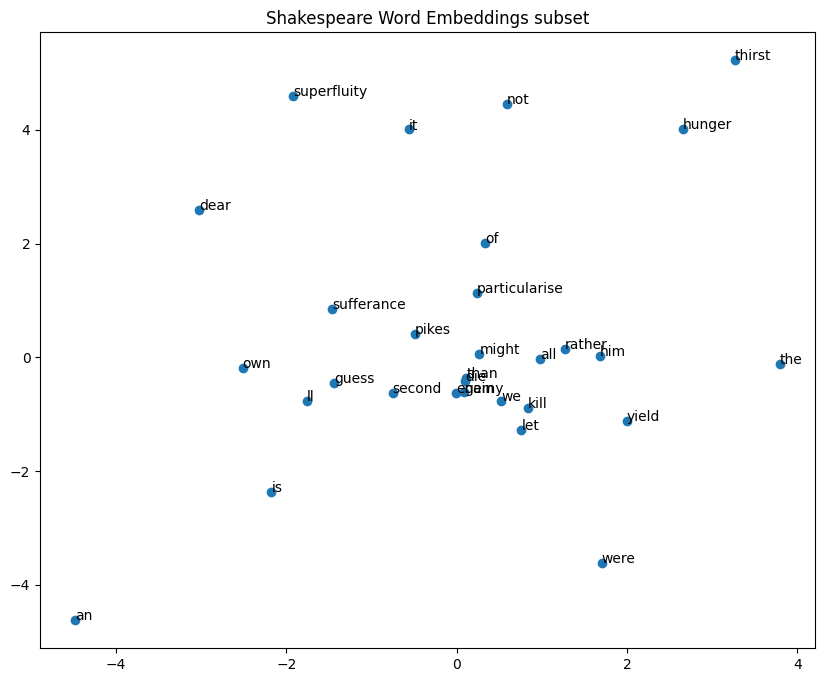

In [6]:
embeddings = model.embed.weight.detach().cpu().numpy()
plt.figure(figsize=(10, 8))
plt.scatter(embeddings[:30, 0], embeddings[:30, 1])
for i in range(30):
    plt.annotate(vocab[i], (embeddings[i, 0], embeddings[i, 1]))
plt.title('Shakespeare Word Embeddings subset')
plt.savefig('word_embeddings.png')